# Proyek Analisis Data: Air Quality Dataset (PRSA)
- **Nama:** Akbar Rezy Hanara Setiyawan
- **Email:** offizier.rezy@gmail.com
- **ID Dicoding:** arezyhs

## Menentukan Pertanyaan Bisnis
- **Pertanyaan 1:** Bagaimana tren rata-rata bulanan konsentrasi polusi (PM2.5) di seluruh stasiun (12 stasiun) pada tahun 2016, dan pada bulan apa tingkat polusi rata-rata mencapai puncaknya?
- **Pertanyaan 2:** Bagaimana pengaruh suhu (TEMP) dan tingkat curah hujan (RAIN) terhadap fluktuasi konsentrasi PM2.5 secara agregat di seluruh stasiun selama musim panas (Juni-Agustus) tahun 2016?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

C:\Users\arezyhs\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:31: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.24.3)
  from scipy.stats import gaussian_kde


## Data Wrangling
### Gathering Data
Kita akan menggabungkan seluruh data dari 12 stasiun pengamatan kualitas udara.

In [2]:
# Mengambil semua file CSV dataset PRSA
path = 'PRSA_Data_20130301-20170228'
all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = []
for file in all_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

# Menggabungkan semuanya ke dalam satu DataFrame
df_air = pd.concat(df_list, ignore_index=True)
print("Total baris dan kolom:", df_air.shape)
df_air.head()

Total baris dan kolom: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### Assessing Data

In [3]:
# Menilai informasi data, tipe data, dan missing value
df_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [4]:
# Cek Missing Values
print("Missing values per kolom:\n", df_air.isnull().sum())

Missing values per kolom:
 No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


In [5]:
# Cek Duplikasi
print("\nTotal duplikasi data:", df_air.duplicated().sum())


Total duplikasi data: 0


**Masalah Data yang Ditemukan:**
1. Terdapat *missing values* (nilai yang hilang) di banyak kolom, khususnya pada polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan beberapa variabel cuaca.
2. Format waktu masih terpisah dalam kolom tahun (`year`), bulan (`month`), hari (`day`), dan jam (`hour`), sebaiknya digabung menjadi satu kolom `datetime` untuk mempermudah analisis *time-series*.

### Cleaning Data

In [6]:
# 1. Menyatukan kolom waktu menjadi satu kolom datetime
df_air['datetime'] = pd.to_datetime(df_air[['year', 'month', 'day', 'hour']])

# 2. Mengatasi missing value menggunakan interpolasi linear untuk polutan & cuaca
cols_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in cols_to_interpolate:
    df_air[col] = df_air[col].interpolate(method='linear', limit_direction='both')
    
# Untuk kolom arah angin (wd) yang berupa kategori, kita isi dengan modus dari masing-masing stasiun
df_air['wd'] = df_air.groupby('station')['wd'].apply(lambda x: x.fillna(x.mode()[0])).reset_index(level=0, drop=True)

# Mengecek kembali missing value
print("Missing values setelah dibersihkan:\n", df_air.isnull().sum())

Missing values setelah dibersihkan:
 No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


In [7]:
# Ekspor data bersih untuk Dashboard
import os
os.makedirs('dashboard', exist_ok=True)
df_air.to_csv('dashboard/main_data.csv', index=False)
print("Data bersih berhasil disimpan ke dashboard/main_data.csv")

Data bersih berhasil disimpan ke dashboard/main_data.csv


## Exploratory Data Analysis (EDA)

In [8]:
# Statistik Deskriptif
df_air.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.839718,104.910268,15.913090,50.600220,1235.682649,57.237872,13.531692,1010.753337,2.482421,0.064428,1.730034
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.950217,92.431422,21.896609,35.170876,1161.790893,57.135195,11.437867,10.474302,13.797675,0.820638,1.246674
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [9]:
# Mengekstrak data hanya untuk tahun 2016
df_2016 = df_air[df_air['year'] == 2016]

# Mengelompokkan rata-rata polusi per bulan di seluruh stasiun
monthly_pm25_2016 = df_2016.groupby('month')['PM2.5'].mean().reset_index()
monthly_pm25_2016

,month,PM2.5
0,1,66.799619
1,2,42.821959
2,3,92.193716
3,4,67.596528
4,5,54.383262
5,6,58.703962
6,7,68.665155
7,8,45.812220
8,9,53.974884
9,10,85.589662


In [10]:
# Menyaring data khusus musim panas (Juni, Juli, Agustus) tahun 2016
summer_2016 = df_2016[df_2016['month'].isin([6, 7, 8])]

# Korelasi
corr_matrix = summer_2016[['TEMP', 'RAIN', 'PM2.5']].corr()
corr_matrix

,TEMP,RAIN,PM2.5
TEMP,1.000000,-0.138795,0.126653
RAIN,-0.138795,1.000000,-0.060895
PM2.5,0.126653,-0.060895,1.000000


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren rata-rata bulanan konsentrasi polusi (PM2.5) di seluruh stasiun (12 stasiun) pada tahun 2016, dan pada bulan apa tingkat polusi rata-rata mencapai puncaknya?

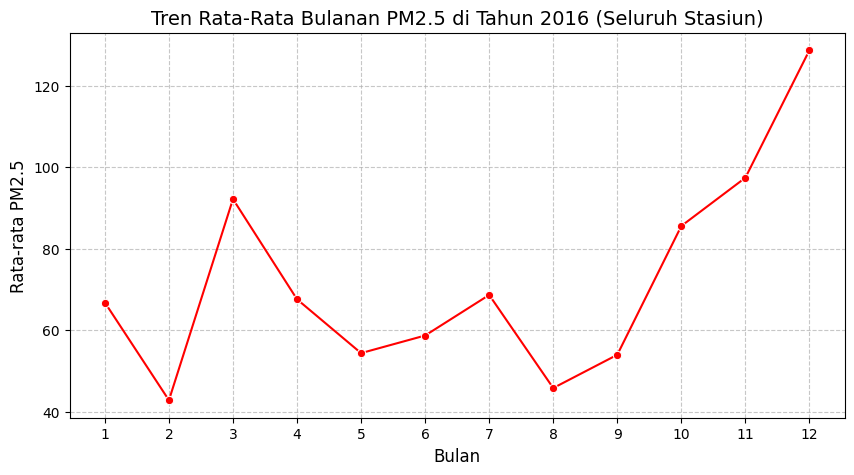

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='month', y='PM2.5', data=monthly_pm25_2016, marker='o', color='red')
plt.title('Tren Rata-Rata Bulanan PM2.5 di Tahun 2016 (Seluruh Stasiun)', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata PM2.5', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Berdasarkan grafik di atas, rata-rata konsentrasi polutan PM2.5 cenderung turun selama musim panas (bulan ke-6 hingga ke-8) dan mulai naik secara drastis saat mendekati akhir tahun, mencapai puncaknya di bulan ke-12 (Desember).

### Pertanyaan 2: Bagaimana pengaruh suhu (TEMP) dan tingkat curah hujan (RAIN) terhadap fluktuasi konsentrasi PM2.5 secara agregat di seluruh stasiun selama musim panas (Juni-Agustus) tahun 2016?

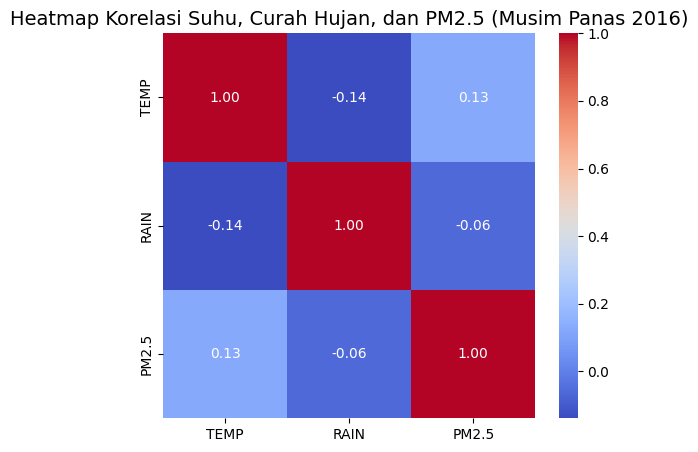

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Suhu, Curah Hujan, dan PM2.5 (Musim Panas 2016)', fontsize=14)
plt.show()

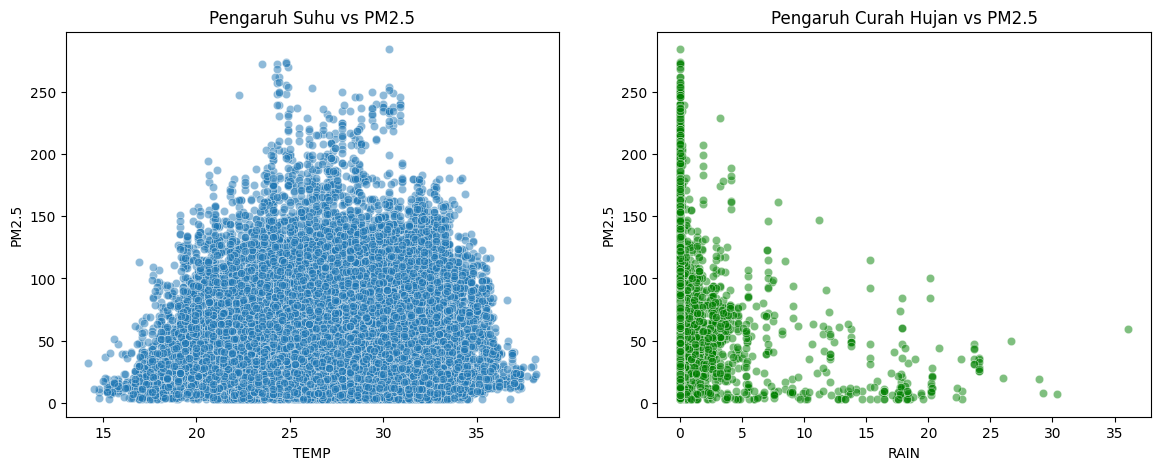

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='TEMP', y='PM2.5', data=summer_2016, alpha=0.5, ax=ax[0])
ax[0].set_title('Pengaruh Suhu vs PM2.5')

sns.scatterplot(x='RAIN', y='PM2.5', data=summer_2016, alpha=0.5, ax=ax[1], color='green')
ax[1].set_title('Pengaruh Curah Hujan vs PM2.5')
plt.show()

Berdasarkan hasil diatas, terdapat pengaruh (korelasi negatif) yang moderat/lemah antara hujan maupun suhu dengan polusi PM2.5. Artinya, saat terjadi peningkatan suhu dan hujan (yang identik dengan cuaca musim panas basah), curah hujan membantu meluruhkan sebagian debu dan PM2.5 sehingga kualitas udara cenderung lebih baik.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Tingkat polusi PM2.5 rata-rata tertinggi terjadi pada bulan Desember (musim dingin), sedangkan yang terendah terjadi di bulan Agustus. Hal ini bisa jadi disebabkan oleh penggunaan sistem pemanas batu bara di bulan-bulan musim dingin serta faktor dispersi atmosferik.
- **Conclusion Pertanyaan 2:** Selama musim panas 2016, suhu dan curah hujan memiliki korelasi negatif dengan konsentrasi PM2.5. Hujan berperan dalam "mencuci" partikel polusi di udara (wet scavenging), sehingga kadar PM2.5 cenderung lebih rendah ketika intensitas hujan/suhu sedang tinggi.

**Rekomendasi Action Item:**
1. **Untuk Pemerintah/Pihak Berwenang:** Mempersiapkan regulasi pembatasan emisi atau sistem peringatan dini kesehatan secara masif menjelang akhir tahun (mulai bulan November hingga puncaknya di Desember) untuk mengantisipasi melonjaknya angka polusi PM2.5.
2. **Untuk Masyarakat:** Disarankan untuk menggunakan masker berfilter tinggi (seperti N95) dan *air purifier* di dalam ruangan terutama saat bulan Desember. Di musim panas, masyarakat bisa lebih leluasa beraktivitas di luar ruangan terutama setelah hujan turun, karena udara relatif lebih bersih.